# 05. Budget Optimization


Compare the planned media allocation for the first 13 test weeks with an MMM-optimized allocation using the same total budget and the same channel-specific weekly flighting pattern.

In [49]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from pymc_marketing.mmm.multidimensional import (
    MMM,
    MultiDimensionalBudgetOptimizerWrapper,
)

root = Path("..")

mmm = MMM.load(
    root / "artifacts/mmm_regularized_with_ppc.nc"
)

test_df = pd.read_csv(
    root / "data/scenario_a/scenario_a_test.csv",
    parse_dates=["date_week"],
)

train_df = pd.read_csv(
    root / "data/scenario_a/scenario_a_train.csv",
    parse_dates=["date_week"],
)
channels = mmm.channel_columns

names = {
    "tv_spend": "TV",
    "google_search_spend": "Google Search",
    "tiktok_spend": "TikTok",
}

In [50]:
start_date = pd.Timestamp("2025-06-30")
end_date = pd.Timestamp("2025-12-22")

optimizer = MultiDimensionalBudgetOptimizerWrapper(
    model=mmm,
    start_date=str(start_date.date()),
    end_date=str(end_date.date()),
)

n_periods = optimizer.num_periods
assert n_periods == 26

# Fixed total budget: $1M
CAMPAIGN_BUDGET = 1000.0  # $000s
budget_per_period = CAMPAIGN_BUDGET / n_periods

# Historical average allocation from the 130 training weeks
historical_totals = train_df[channels].sum()
historical_shares = historical_totals / historical_totals.sum()

# Business-as-usual allocation for the next 26 weeks
planned_campaign = historical_shares * CAMPAIGN_BUDGET

planned_allocation = xr.DataArray(
    (planned_campaign / n_periods).to_numpy(),
    dims=["channel"],
    coords={"channel": channels},
)

# Spend evenly across the 26 weeks
future_dates = pd.date_range(
    start=start_date,
    end=end_date,
    freq="W-MON",
)

budget_distribution = xr.DataArray(
    np.full((n_periods, len(channels)), 1 / n_periods),
    dims=["date", "channel"],
    coords={
        "date": future_dates,
        "channel": channels,
    },
)

assert np.allclose(budget_distribution.sum("date").values, 1.0)
assert np.isclose(planned_campaign.sum(), 1000.0)

print(f"Planning window: {start_date.date()} to {end_date.date()}")
print("Campaign budget: $1,000,000")
print(f"Average weekly budget: ${budget_per_period * 1000:,.0f}")

display(
    (planned_campaign * 1000)
    .rename(index=names)
    .rename("Business-as-Usual Spend ($)")
    .to_frame()
)

Planning window: 2025-06-30 to 2025-12-22
Campaign budget: $1,000,000
Average weekly budget: $38,462


,Business-as-Usual Spend ($)
TV,313364.133305
Google Search,453192.230511
TikTok,233443.636184


In [51]:
lower = 0.5 * planned_allocation.values
upper = 1.5 * planned_allocation.values

budget_bounds = xr.DataArray(
    np.column_stack([lower, upper]),
    dims=["channel", "bound"],
    coords={
        "channel": channels,
        "bound": ["lower", "upper"],
    },
)
optimal_allocation, result = optimizer.optimize_budget(
    budget=budget_per_period,
    budget_bounds=budget_bounds,
    budget_distribution_over_period=budget_distribution,
    x0=planned_allocation.values,
    minimize_kwargs={
        "method": "SLSQP",
        "options": {
            "ftol": 1e-9,
            "maxiter": 10_000,
        },
    },
)

assert result.success, result.message

print(result.message)
print(f"Iterations: {result.nit}")

Optimization terminated successfully
Iterations: 2


/opt/miniconda3/envs/walmart_mmm_312/lib/python3.12/site-packages/pymc_marketing/mmm/budget_optimizer.py:808: UserWarning: Using default equality constraint
  self.set_constraints(


,Planned ($),Optimized ($),Planned Share,Optimized Share
TV,313364.0,156682.0,0.313,0.157
Google Search,453192.0,679788.0,0.453,0.680
TikTok,233444.0,163530.0,0.233,0.164


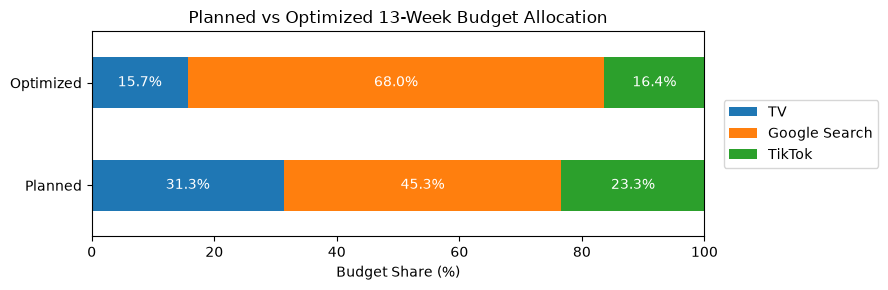

In [52]:
planned_campaign = (
    planned_allocation.to_series()
    .reindex(channels)
    * n_periods
)

optimized_campaign = (
    optimal_allocation.to_series()
    .reindex(channels)
    * n_periods
)

allocation = pd.DataFrame(
    {
        "Planned ($)": planned_campaign * 1000,
        "Optimized ($)": optimized_campaign * 1000,
    }
)

allocation.index = [names[c] for c in channels]

allocation["Planned Share"] = (
    allocation["Planned ($)"]
    / allocation["Planned ($)"].sum()
)

allocation["Optimized Share"] = (
    allocation["Optimized ($)"]
    / allocation["Optimized ($)"].sum()
)

display(
    allocation.round({
        "Planned ($)": 0,
        "Optimized ($)": 0,
        "Planned Share": 3,
        "Optimized Share": 3,
    })
)

shares = (
    allocation[["Planned Share", "Optimized Share"]]
    .T
    * 100
)

shares.index = ["Planned", "Optimized"]

ax = shares.plot(
    kind="barh",
    stacked=True,
    figsize=(9, 3),
)

ax.set_title("Planned vs Optimized 13-Week Budget Allocation")
ax.set_xlabel("Budget Share (%)")
ax.set_ylabel("")
ax.set_xlim(0, 100)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
)

for container in ax.containers:
    labels = [
        f"{value:.1f}%" if value >= 5 else ""
        for value in container.datavalues
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        color="white",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

In [53]:
response_planned = optimizer.sample_response_distribution(
    allocation_strategy=planned_allocation,
    budget_distribution_over_period=budget_distribution,
    noise_level=0,
    include_last_observations=True,
    include_carryover=True,
)

response_optimized = optimizer.sample_response_distribution(
    allocation_strategy=optimal_allocation,
    budget_distribution_over_period=budget_distribution,
    noise_level=0,
    include_last_observations=True,
    include_carryover=True,
)

metric = "total_media_contribution_original_scale"

planned_response = response_planned[metric]
optimized_response = response_optimized[metric]

planned_mean = planned_response.mean().item()
optimized_mean = optimized_response.mean().item()

increase = optimized_mean - planned_mean
uplift_pct = increase / planned_mean * 100

print(f"Planned expected media contribution:   {planned_mean:,.2f}")
print(f"Optimized expected media contribution: {optimized_mean:,.2f}")
print(f"Expected increase:                     {increase:,.2f}")
print(f"Expected uplift:                       {uplift_pct:.2f}%")

Sampling: [y]
Sampling: [y]


Planned expected media contribution:   2,991.56
Optimized expected media contribution: 3,099.66
Expected increase:                     108.10
Expected uplift:                       3.61%


In [54]:
response_planned = optimizer.sample_response_distribution(
    allocation_strategy=planned_allocation,
    budget_distribution_over_period=budget_distribution,
    noise_level=0,
    include_last_observations=True,
    include_carryover=True,
)

response_optimized = optimizer.sample_response_distribution(
    allocation_strategy=optimal_allocation,
    budget_distribution_over_period=budget_distribution,
    noise_level=0,
    include_last_observations=True,
    include_carryover=True,
)

metric = "total_media_contribution_original_scale"

planned_response = response_planned[metric]
optimized_response = response_optimized[metric]

planned_mean = planned_response.mean().item()
optimized_mean = optimized_response.mean().item()

increase = optimized_mean - planned_mean
uplift_pct = increase / planned_mean * 100

print(f"Planned expected media contribution:   {planned_mean:,.2f}")
print(f"Optimized expected media contribution: {optimized_mean:,.2f}")
print(f"Expected increase:                     {increase:,.2f}")
print(f"Expected uplift:                       {uplift_pct:.2f}%")

Sampling: [y]
Sampling: [y]


Planned expected media contribution:   2,991.56
Optimized expected media contribution: 3,099.66
Expected increase:                     108.10
Expected uplift:                       3.61%
